# Install Required Libraries

In [1]:
# Install required libraries

!pip install contractions
!pip install wordcloud
!pip install nltk
!pip install gensim

In [2]:
import tensorflow as tf

print(tf.__version__)

2.21.0


# Import Libraries

In [3]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import re
import nltk
import contractions

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visualization
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# TensorFlow / Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
!pip install --upgrade tensorflow

In [5]:
!pip uninstall -y jax jaxlib

# Load Dataset

In [6]:
# Load dataset

df = pd.read_csv('/content/drive/MyDrive/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv')

# Display first 5 rows
df.head()

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


# Understand Dataset (EDA)

In [7]:
# Number of rows and columns
print(df.shape)

# Dataset info
df.info()

# Check missing values
df.isnull().sum()


(24783, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   24783 non-null  object
 1   text    24783 non-null  object
dtypes: object(2)
memory usage: 387.4+ KB


,0
label,0
text,0


In [8]:
# Count labels

df['label'].value_counts()

,count
label,
offensive language,19190
neither,4163
hate speec,1430


# Plot Class Distribution

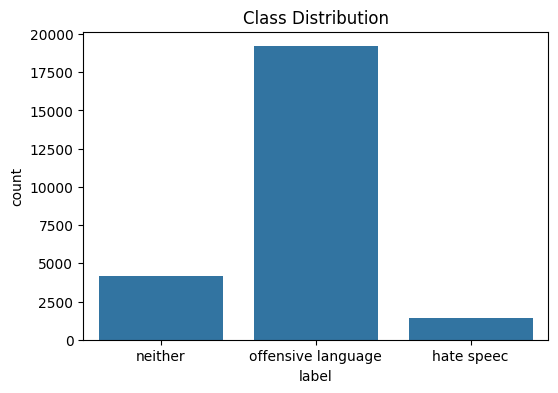

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Class Distribution")
plt.show()

# Text Cleaning

# Create Cleaning Function

In [10]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove RT
    text = re.sub(r'\brt\b', '', text)

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [11]:
df.columns

Index(['label', 'text'], dtype='object')

# Apply Cleaning

In [12]:


# # Clean text

# df['clean_text'] = df['text'].apply(clean_text)

# # Show cleaned text
# df[['text', 'clean_text']].head()

# Clean text

df['clean_text'] = df['text'].apply(clean_text)

# Show cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman complain cleaning house amp man always t...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat coldtyga dwn bad cuffin dat hoe st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg ever fuck bitch start cry confused shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear might true might faker bitch told ya


# Word Cloud Visualization

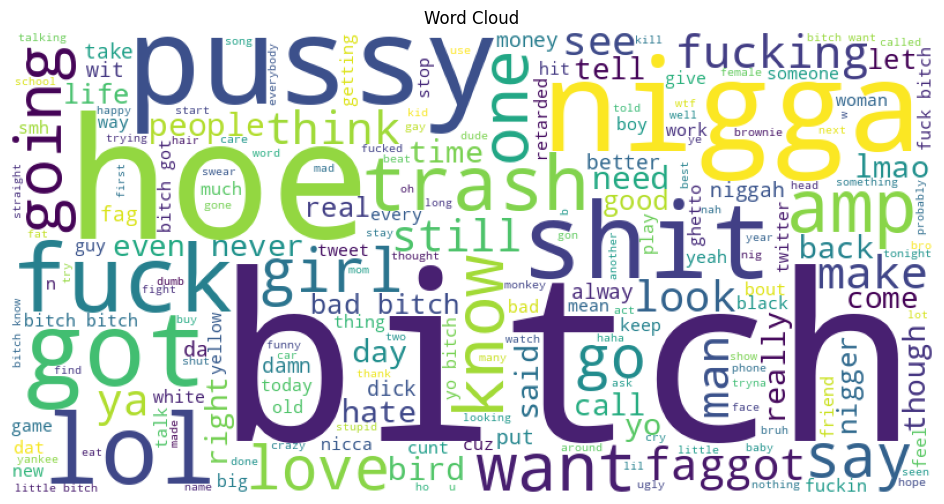

In [13]:
# Combine all cleaned text

all_words = " ".join(df['clean_text'])

# Generate wordcloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

# Plot

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud")

plt.show()

# Most Frequent Words

In [14]:
from collections import Counter

words = all_words.split()

common_words = Counter(words).most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

common_df

,Word,Count
0,bitch,11305
1,hoe,4274
2,like,2819
3,pussy,2201
4,nigga,1988
5,got,1600
6,as,1567
7,get,1536
8,fuck,1447
9,shit,1279


In [15]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

# Convert text labels to numbers
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Show mapping
print(dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
)))

{'hate speec': np.int64(0), 'neither': np.int64(1), 'offensive language': np.int64(2)}


# Train Test Split

In [16]:
# Features and labels

X = df['clean_text']
y = df['label']

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 19826
Testing samples: 4957


# Tokenization

In [17]:
# ==========================================
# TOKENIZATION
# ==========================================

from tensorflow.keras.preprocessing.text import Tokenizer

# Vocabulary size

vocab_size = 10000

# Tokenizer

tokenizer = Tokenizer(num_words=vocab_size)

# Fit tokenizer

tokenizer.fit_on_texts(X_train)

# Convert text to sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding

In [18]:
# Calculate lengths

sequence_lengths = [len(seq) for seq in X_train_seq]

print(sequence_lengths[:10])


# 95th percentile length
max_length = int(np.percentile(sequence_lengths, 95))
print("Max Length:", max_length)

# Padding sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

[13, 10, 4, 3, 2, 9, 3, 5, 4, 12]
Max Length: 13
(19826, 13)
(4957, 13)


In [26]:
# Create encoder
label_encoder = LabelEncoder()

# Convert text labels into numbers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert datatype
y_train_encoded = np.array(y_train_encoded).astype(np.int32)

# Convert X data too
X_train_pad = np.array(X_train_pad).astype(np.int32)

# Check result
print(y_train_encoded[:10])
print(X_train_pad.dtype)
print(y_train_encoded.dtype)

[0 1 2 2 2 2 2 1 2 2]
int32
int32


# Build MODEL 1 (Simple RNN)

In [27]:
from tensorflow.keras import Input
# Number of classes
num_classes = len(df['label_encoded'].unique())

# Build Simple RNN model

rnn_model = Sequential([

    # Input layer
    Input(shape=(max_length,)),

    # Embedding layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # Simple RNN layer
    SimpleRNN(64),

    # Dropout layer
    Dropout(0.5),

    # Dense hidden layer
    Dense(32, activation='relu'),

    # Output layer
    Dense(num_classes, activation='softmax')

])

# Compile model

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,531 (4.94 MB)

 Trainable params: 1,294,531 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Early stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train model

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8421 - loss: 0.4450 - val_accuracy: 0.8926 - val_loss: 0.3214
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9144 - loss: 0.2596 - val_accuracy: 0.8880 - val_loss: 0.3117
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9447 - loss: 0.1691 - val_accuracy: 0.8883 - val_loss: 0.3706
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9661 - loss: 0.1057 - val_accuracy: 0.8623 - val_loss: 0.4522
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9759 - loss: 0.0772 - val_accuracy: 0.8835 - val_loss: 0.4953


# Plot Accuracy & Loss

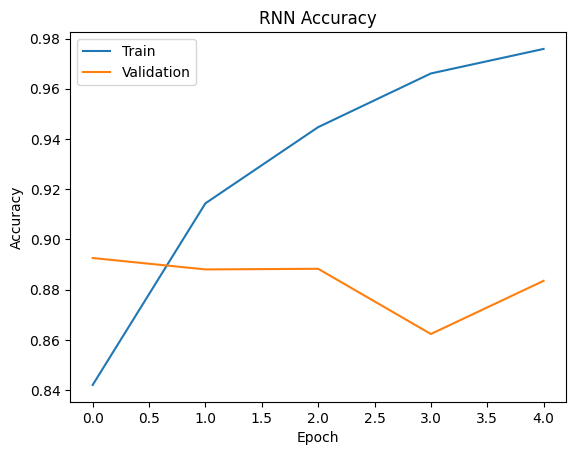

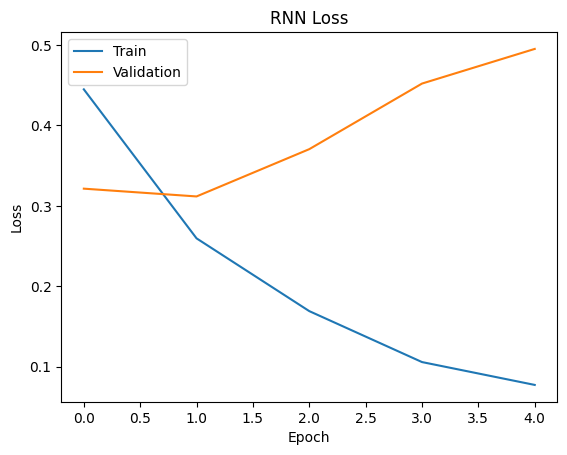

In [30]:
# Accuracy Plot

plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title('RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()


# Loss Plot

plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])

plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [31]:
df['label'].unique()

array(['neither', 'offensive language', 'hate speec'], dtype=object)

# Evaluate MODEL 1

In [33]:
# Encode test labels too
y_test_encoded = label_encoder.transform(y_test)

# Convert datatype
y_test_encoded = np.array(y_test_encoded).astype(np.int32)

In [66]:
# Predictions
y_pred = rnn_model.predict(X_test_pad)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8755295541658261

Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.27      0.32       290
           1       0.76      0.86      0.81       835
           2       0.93      0.93      0.93      3832

    accuracy                           0.88      4957
   macro avg       0.69      0.68      0.68      4957
weighted avg       0.87      0.88      0.87      4957



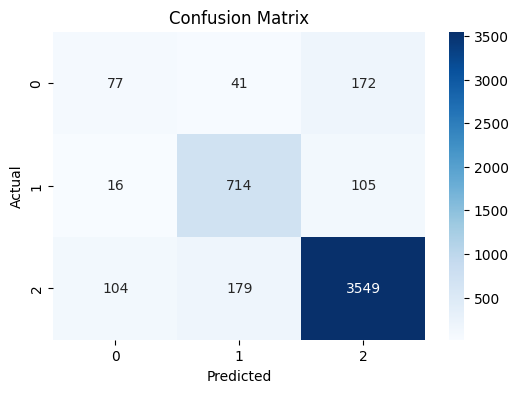

In [37]:
# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Build LSTM Model

In [38]:

# Number of classes
num_classes = len(df['label_encoded'].unique())

# Build LSTM model

lstm_model = Sequential([

    # Input layer
    Input(shape=(max_length,)),

    # Embedding layer
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    # LSTM layer
    LSTM(128),

    # Dropout
    Dropout(0.5),

    # Dense layer
    Dense(64, activation='relu'),

    # Output layer
    Dense(num_classes, activation='softmax')

])

# Compile model

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

#Train LSTM Model

In [40]:
# TRAIN LSTM MODEL

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(

    X_train_pad,

    y_train_encoded,

    validation_split=0.2,

    epochs=10,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8561 - loss: 0.4080 - val_accuracy: 0.8991 - val_loss: 0.3053
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9124 - loss: 0.2648 - val_accuracy: 0.9019 - val_loss: 0.3034
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9323 - loss: 0.2009 - val_accuracy: 0.8886 - val_loss: 0.3154
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9511 - loss: 0.1505 - val_accuracy: 0.8941 - val_loss: 0.3858
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9625 - loss: 0.1180 - val_accuracy: 0.8848 - val_loss: 0.4761


# Plot LSTM Accuracy and Loss

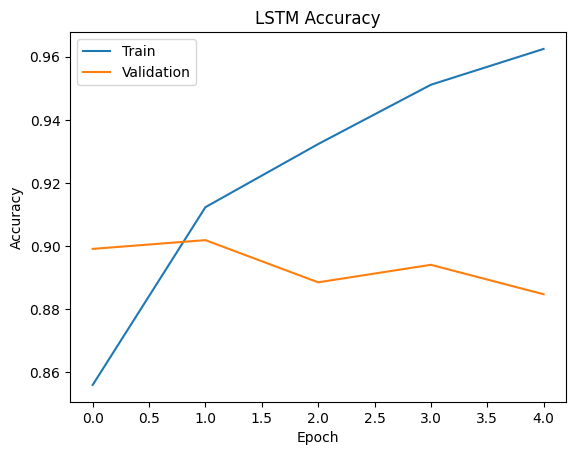

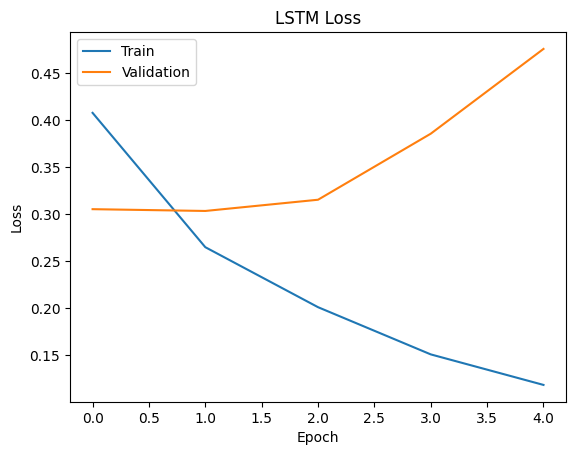

In [41]:
# LSTM ACCURACY PLOT

plt.plot(history_lstm.history['accuracy'])

plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()



# LSTM LOSS PLOT


plt.plot(history_lstm.history['loss'])

plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

#Evaluate LSTM

In [67]:
# LSTM EVALUATION

# Predictions
y_pred_lstm = lstm_model.predict(X_test_pad)

# Convert probabilities to labels
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)

# Accuracy
print("LSTM Accuracy:",
      accuracy_score(y_test_encoded, y_pred_lstm))

# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test_encoded,
    y_pred_lstm
))

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Accuracy: 0.8882388541456526

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.02      0.04       290
           1       0.81      0.84      0.82       835
           2       0.91      0.96      0.93      3832

    accuracy                           0.89      4957
   macro avg       0.74      0.61      0.60      4957
weighted avg       0.87      0.89      0.86      4957



#Confusion Matrix

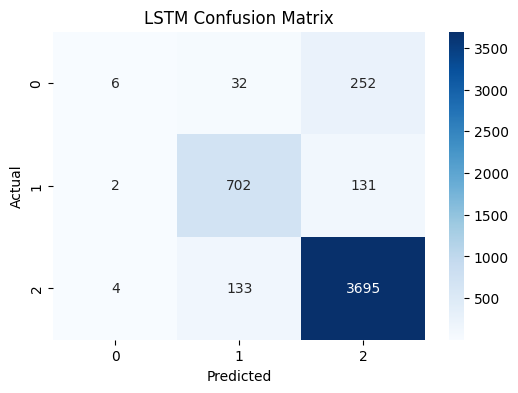

In [44]:
cm = confusion_matrix(
    y_test_encoded,
    y_pred_lstm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# LSTM with pretrained Word2Vec embeddings.

In [45]:
# Install Compatible Versions
!pip install numpy==1.23.5
!pip install gensim
!pip install jax==0.4.13

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached jax-0.4.13-py3-none-any.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0

#Import Word2Vec Libraries

In [46]:
import gensim.downloader as api

# Load pretrained embeddings
embedding_model = api.load('glove-wiki-gigaword-50')

#CREATE EMBEDDING MATRIX


In [47]:
# CREATE EMBEDDING MATRIX

embedding_dim = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim)
)

for word, i in word_index.items():

    if i >= vocab_size:
        continue

    if word in embedding_model:

        embedding_vector = embedding_model[word]

        embedding_matrix[i] = embedding_vector

#Build Word2Vec LSTM Model

In [51]:
# LSTM + WORD2VEC MODEL

num_classes = len(df['label_encoded'].unique())

word2vec_model = Sequential([

    # Input layer
    Input(shape=(max_length,)),

    # Pretrained Embedding Layer
    Embedding(

        input_dim=vocab_size,

        output_dim=embedding_dim,

        weights=[embedding_matrix],

        trainable=False

    ),

    # LSTM Layer
    LSTM(128),

    # Dropout
    Dropout(0.5),

    # Dense layer
    Dense(64, activation='relu'),

    # Output layer
    Dense(num_classes, activation='softmax')

])

# Compile model

word2vec_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# Model summary

word2vec_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,099 (2.29 MB)

 Trainable params: 100,099 (391.01 KB)

 Non-trainable params: 500,000 (1.91 MB)

#Train Word2Vec Model

In [53]:

# TRAIN WORD2VEC MODEL

# Ensure numeric datatype
X_train_pad = np.array(X_train_pad).astype(np.int32)

y_train_encoded = np.array(y_train_encoded).astype(np.int32)

# Early stopping
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

# Train model
history_word2vec = word2vec_model.fit(

    X_train_pad,

    y_train_encoded,

    validation_split=0.2,

    epochs=10,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8468 - loss: 0.4375 - val_accuracy: 0.8712 - val_loss: 0.3327
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8696 - loss: 0.3384 - val_accuracy: 0.8845 - val_loss: 0.3072
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8788 - loss: 0.3110 - val_accuracy: 0.8739 - val_loss: 0.3091
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8859 - loss: 0.2911 - val_accuracy: 0.8840 - val_loss: 0.2924
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8917 - loss: 0.2779 - val_accuracy: 0.8863 - val_loss: 0.2940
Epoch 6/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8964 - loss: 0.2642 - val_accuracy: 0.8787 - val_loss: 0.3149
Epoch 7/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9023 - loss: 0.2520 - val_accuracy: 0.8893 - val_loss: 0.2936


# Plot Accuracy and Loss

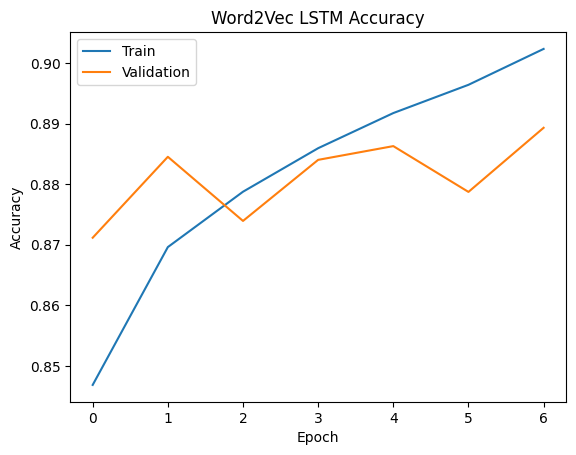

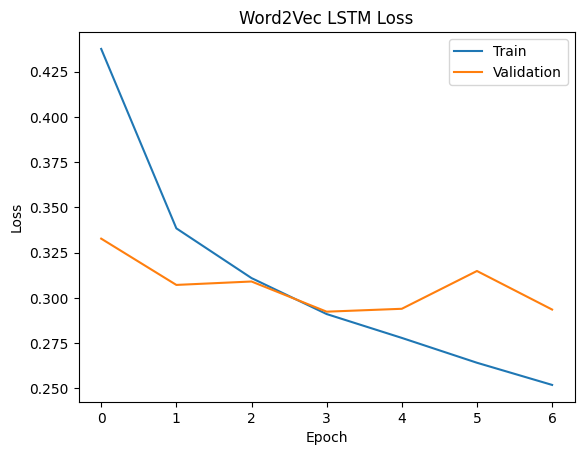

In [56]:
# WORD2VEC ACCURACY PLOT

plt.plot(history_word2vec.history['accuracy'])
plt.plot(history_word2vec.history['val_accuracy'])
plt.title("Word2Vec LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()


# WORD2VEC LOSS PLOT
plt.plot(history_word2vec.history['loss'])
plt.plot(history_word2vec.history['val_loss'])
plt.title("Word2Vec LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

#Evaluate Word2Vec Model

In [68]:
# WORD2VEC EVALUATION

# Predictions
y_pred_word2vec = word2vec_model.predict(X_test_pad)

# Convert probabilities to labels
y_pred_word2vec = np.argmax(
    y_pred_word2vec,
    axis=1
)

# Accuracy
print(
    "Word2Vec Accuracy:",
    accuracy_score(
        y_test_encoded,
        y_pred_word2vec
    )
)

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_word2vec
    )
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Word2Vec Accuracy: 0.8813798668549526

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.33      0.39       290
           1       0.81      0.78      0.80       835
           2       0.92      0.94      0.93      3832

    accuracy                           0.88      4957
   macro avg       0.74      0.69      0.71      4957
weighted avg       0.87      0.88      0.88      4957



#Confusion Matrix

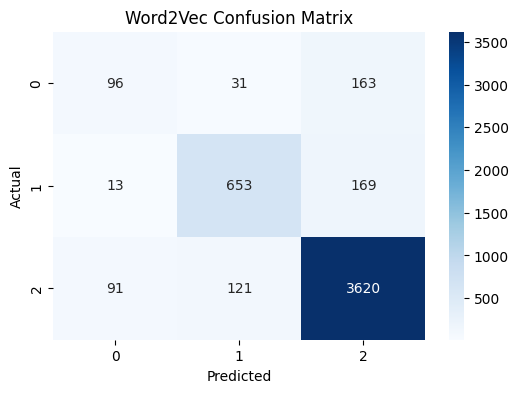

In [60]:
# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_word2vec
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Word2Vec Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#COMPARISON GRAPHS

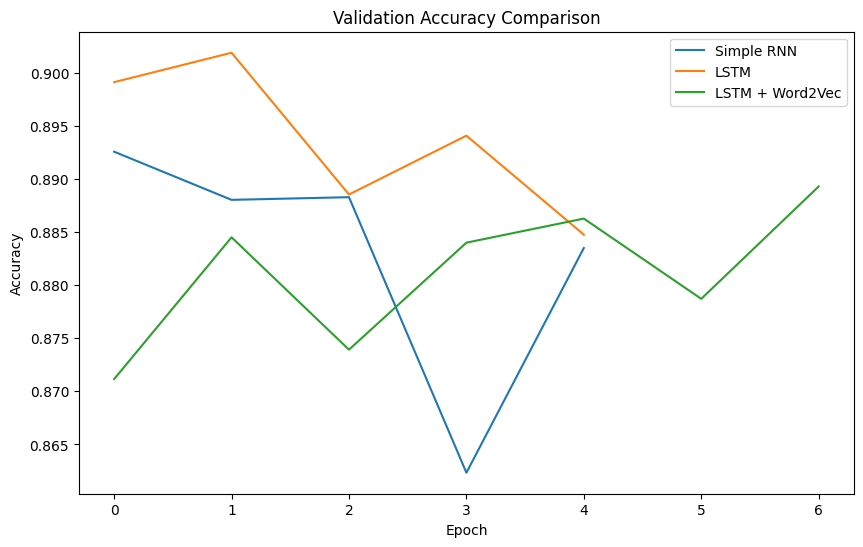

In [69]:
# VALIDATION ACCURACY COMPARISON

plt.figure(figsize=(10,6))

# RNN
plt.plot(
    history_rnn.history['val_accuracy'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

# Word2Vec
plt.plot(
    history_word2vec.history['val_accuracy'],
    label='LSTM + Word2Vec'
)

# Labels
plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

#Compare Validation Loss

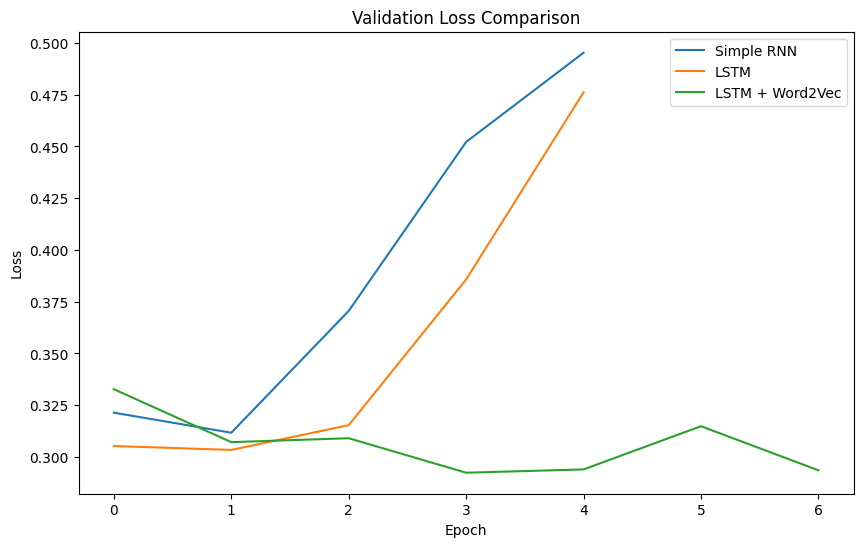

In [70]:
# VALIDATION LOSS COMPARISON

plt.figure(figsize=(10,6))

# RNN
plt.plot(
    history_rnn.history['val_loss'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM'
)

# Word2Vec
plt.plot(
    history_word2vec.history['val_loss'],
    label='LSTM + Word2Vec'
)

# Labels
plt.title("Validation Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

#Final Accuracy Comparison Bar Chart

Simple RNN Accuracy : 0.8755295541658261
LSTM Accuracy : 0.8882388541456526
LSTM + Word2Vec Accuracy : 0.8813798668549526


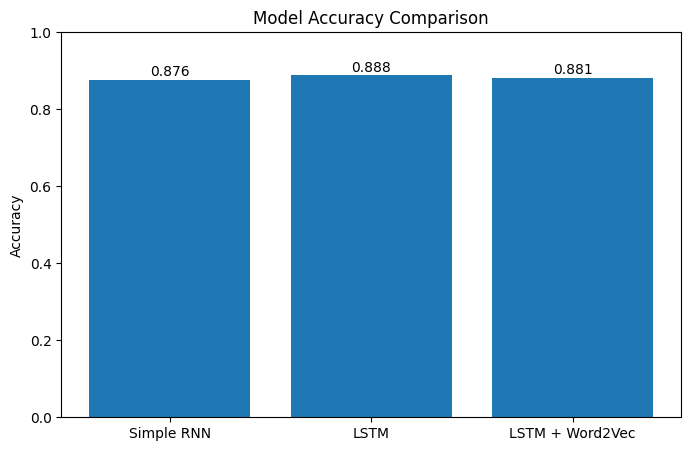

In [75]:
# FINAL ACCURACY BAR CHART

# Accuracy scores

rnn_acc = accuracy_score(
    y_test_encoded,
    y_pred
)

lstm_acc = accuracy_score(
    y_test_encoded,
    y_pred_lstm
)

word2vec_acc = accuracy_score(
    y_test_encoded,
    y_pred_word2vec
)

# Print accuracies

print("Simple RNN Accuracy :", rnn_acc)

print("LSTM Accuracy :", lstm_acc)

print("LSTM + Word2Vec Accuracy :", word2vec_acc)

# Models

models = [
    'Simple RNN',
    'LSTM',
    'LSTM + Word2Vec'
]

# Accuracy values

accuracies = [
    rnn_acc,
    lstm_acc,
    word2vec_acc
]

# Plot

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

# Add accuracy values on bars

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        round(yval, 3),
        ha='center'
    )

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

In [77]:
# MODEL COMPARISON TABLE

# Recalculate accuracies correctly

rnn_acc = accuracy_score(
    y_test_encoded,
    y_pred
)

lstm_acc = accuracy_score(
    y_test_encoded,
    y_pred_lstm
)

word2vec_acc = accuracy_score(
    y_test_encoded,
    y_pred_word2vec
)

# Create comparison table

comparison_df = pd.DataFrame({

    'Model': [
        'Simple RNN',
        'LSTM',
        'LSTM + Word2Vec'
    ],

    'Accuracy': [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ]

})

# Round values

comparison_df['Accuracy'] = comparison_df[
    'Accuracy'
].round(4)

# Display table

comparison_df

,Model,Accuracy
0,Simple RNN,0.8755
1,LSTM,0.8882
2,LSTM + Word2Vec,0.8814


        Model  Accuracy  Validation Loss
0  Simple RNN    0.8755           0.4953
1        LSTM    0.8882           0.4761


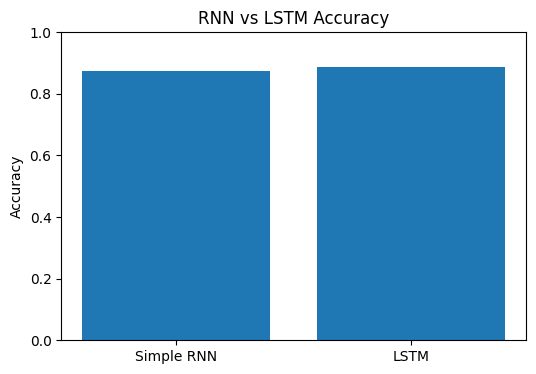

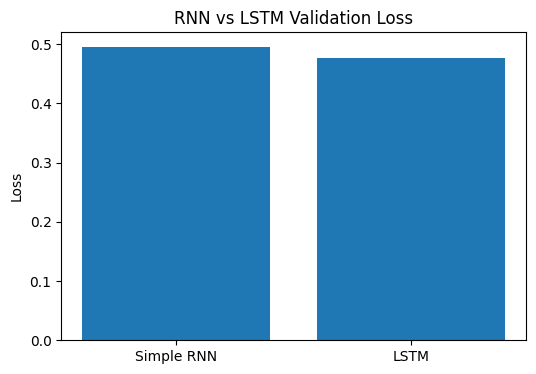

In [81]:
#RNN vs LSTM PERFORMANCE COMPARISON

# Accuracy

rnn_acc = accuracy_score(
    y_test_encoded,
    y_pred
)

lstm_acc = accuracy_score(
    y_test_encoded,
    y_pred_lstm
)

# Validation Loss

rnn_loss = history_rnn.history['val_loss'][-1]
lstm_loss = history_lstm.history['val_loss'][-1]

# Comparison Table
comparison_df = pd.DataFrame({

    'Model': ['Simple RNN', 'LSTM'],

    'Accuracy': [rnn_acc, lstm_acc],

    'Validation Loss': [rnn_loss, lstm_loss]

})

# Round values
comparison_df = comparison_df.round(4)
# Display table
print(comparison_df)

# ACCURACY COMPARISON GRAPH


plt.figure(figsize=(6,4))
plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)
plt.title("RNN vs LSTM Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# LOSS COMPARISON GRAPH


plt.figure(figsize=(6,4))
plt.bar(
    comparison_df['Model'],
    comparison_df['Validation Loss']
)
plt.title("RNN vs LSTM Validation Loss")
plt.ylabel("Loss")
plt.show()

#Error Analysis

In [90]:
# Predict using LSTM
y_pred_lstm = lstm_model.predict(X_test_pad)

# Convert probabilities to labels
y_pred_lstm = np.argmax(
    y_pred_lstm,
    axis=1
)

# Find incorrect predictions

misclassified = np.where(
    y_test_encoded != y_pred_lstm
)[0]

# Total errors
print(
    "Total Misclassified:",
    len(misclassified)
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total Misclassified: 554


#Show Incorrect Predictions

In [91]:

# DISPLAY MISCLASSIFIED EXAMPLES

# Convert X_test to list
X_test_list = list(X_test)

# Show first 5 incorrect predictions
for i in misclassified[:5]:

    print("\n================================")
    print("Tweet:")
    print(X_test_list[i])

    # Actual label
    print(
        "\nActual Label:",
        label_names[y_test_encoded[i]]
    )

    # Predicted label
    print(
        "Predicted Label:",
        label_names[y_pred_lstm[i]]
    )

    print("================================")


Tweet:
lol credit near good know right man job ho nice though

Actual Label: neither
Predicted Label: offensive language

Tweet:
search gay redneck episode play

Actual Label: hate speec
Predicted Label: offensive language

Tweet:
got love islamofascist cow try make retort age typical muzzie idiocy

Actual Label: hate speec
Predicted Label: neither

Tweet:
say waste draft pick manziel mallet telling delete account retarded

Actual Label: hate speec
Predicted Label: offensive language

Tweet:
aight game dyke ruin

Actual Label: hate speec
Predicted Label: offensive language


#Convert Numeric Labels Back to Original Labels

In [86]:
# Label names
label_names = label_encoder.classes_

# Find misclassified samples

misclassified = np.where(
    y_test_encoded != y_pred_lstm
)[0]

# Show first 5 errors

for i in misclassified[:5]:

    print("\n==============================")

    print("Tweet:")
    print(X_test_list[i])

    # Actual label
    print(
        "\nActual Label:",
        label_names[y_test_encoded[i]]
    )

    # Predicted label
    print(
        "Predicted Label:",
        label_names[y_pred_lstm[i]]
    )

    print("==============================")


Tweet:
lol credit near good know right man job ho nice though

Actual Label: neither
Predicted Label: offensive language

Tweet:
search gay redneck episode play

Actual Label: hate speec
Predicted Label: offensive language

Tweet:
got love islamofascist cow try make retort age typical muzzie idiocy

Actual Label: hate speec
Predicted Label: neither

Tweet:
say waste draft pick manziel mallet telling delete account retarded

Actual Label: hate speec
Predicted Label: offensive language

Tweet:
aight game dyke ruin

Actual Label: hate speec
Predicted Label: offensive language


#The model misclassified some tweets because of sarcasm, slang, abbreviations, and unclear context. Some offensive words were used in non-hateful sentences, which confused the model between hate speech and offensive language classes. Short tweets and informal spellings also reduced prediction accuracy. Although the LSTM model performed better than the Simple RNN model, some errors still occurred because deep learning models cannot fully understand human intention and implicit meaning in text.

#GUI for Real Time Prediction #

In [92]:
#Install Gradio
!pip install gradio

#Create Prediction Function

In [93]:
# REAL-TIME PREDICTION FUNCTION

def predict_hate_speech(text):

    # Clean text
    cleaned = clean_text(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    # Prediction
    prediction = lstm_model.predict(padded)

    # Get class index
    predicted_class = np.argmax(prediction)

    # Convert label
    result = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    return result

#Build Gradio Interface

In [94]:
# GRADIO INTERFACE

import gradio as gr

interface = gr.Interface(

    fn=predict_hate_speech,

    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a tweet here..."
    ),

    outputs="text",

    title="Hate Speech Detection System",

    description="Enter a tweet and the model will predict the class."

)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31388d570dbece5a58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
